<a href="https://colab.research.google.com/github/porfaanotamicorreo/XM_API/blob/main/upme_pronostico_generacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UPME — Pronóstico de generación eléctrica total (GWh)

Este cuaderno descarga el dataset abierto de UPME **"Producción de electricidad por fuente de combustible"** (datos.gov.co, id `tq63-itzr`), calcula la generación **total mensual** del sistema (todas las fuentes sumadas) y pronostica el mes siguiente al último dato disponible con un modelo SARIMA estacional.

**Dos cosas para tener en cuenta antes de correrlo:**

1. **El límite de "1.000 filas" que se ve en el portal es solo del diálogo de exportación web**, no de la API. Aquí se pagina el endpoint `/resource/tq63-itzr.json` con `$limit`/`$offset` hasta traer todo el histórico (~2.786 filas, sin necesidad de token).
2. **El dataset es mensual**, no diario ni semanal. El pronóstico "real" (SARIMA) es para el mes siguiente; el estimado "semanal" que se calcula después es ese pronóstico mensual repartido proporcionalmente entre 7 días — una referencia de orden de magnitud, no un modelo independiente de la variabilidad semanal (esa variabilidad no existe en la fuente de datos). Si más adelante quieres una predicción semanal real, ese dato lo tiene XM (operador del mercado): https://github.com/EquipoAnaliticaXM/API_XM

Corre las celdas en orden.

## 1. Instalar dependencias

`statsmodels` ya viene preinstalado en Colab; el `pip install` de abajo es solo por seguridad, no debería tardar si ya está.

In [ ]:
!pip install -q statsmodels requests pandas matplotlib

## 2. Imports y configuración

In [ ]:
from __future__ import annotations

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

In [ ]:
DATASET_ID = "tq63-itzr"
BASE_URL = f"https://www.datos.gov.co/resource/{DATASET_ID}.json"

# Si vas a correr esto seguido, saca un App Token gratis en
# https://www.datos.gov.co/profile/edit/developer_settings
# y pégalo aquí (opcional para una corrida puntual):
APP_TOKEN = "qxUkXCO8dDvsdPRKmQUoN2isC"  # p.ej. "abcdEFGH12345token" o puedes usar none si no vas a usar la app todo el tiempo

# Paleta consistente con el resto del flujo UPME
COLOR_HIST = "#2a78d6"
COLOR_FCST = "#eb6834"
COLOR_GRID = "#e1e0d9"
COLOR_MUTED = "#898781"
COLOR_INK = "#0b0b0b"

## 3. Descargar el dataset completo

Pagina el endpoint de a 5.000 filas hasta que la API devuelva una página vacía. Esto evita por completo el límite de 1.000 filas del diálogo de exportación web.

In [ ]:
def descargar_dataset(page_size: int = 5000) -> pd.DataFrame:
    rows: list[dict] = []
    offset = 0
    headers = {"X-App-Token": APP_TOKEN} if APP_TOKEN else {}
    while True:
        params = {"$limit": page_size, "$offset": offset, "$order": "ano,mes"}
        resp = requests.get(BASE_URL, params=params, headers=headers, timeout=30)
        resp.raise_for_status()
        batch = resp.json()
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < page_size:
            break
        offset += page_size
    return pd.DataFrame(rows)


print("Descargando dataset completo de UPME (producción por fuente)...")
df = descargar_dataset()
print(f"{len(df)} filas descargadas.")
df.head()

Descargando dataset completo de UPME (producción por fuente)...
2786 filas descargadas.


,ano,mes,fuente,promedio_mensual_gwh,maximo_gwh,minimo_gwh,generacion_total_gwh,porcentaje_participacion
0,2000,1,ACPM,1.577589611111111,2.683876,0.5307066,14.1983065,0.426629829719028
1,2000,1,AGUA,70.27965954290322,76.4053852,57.62908886,2178.66944583,65.46452386335666
2,2000,1,BAGAZO,0.2536151724137931,0.29835,0.19132,7.35484,0.2209977744043415
3,2000,1,CARBON,8.514893548387096,13.3384,4.0846,263.9617,7.931504727225402
4,2000,1,COMBUSTOLEO,1.525638977096774,2.0785226,1.02953258,47.29480829,1.421111454901806


## 4. Construir la serie mensual de generación total

Suma `generacion_total_gwh` de todas las fuentes (hidráulica, gas, carbón, viento, solar, etc.) agrupando por (año, mes) → generación total del sistema, mes a mes.

In [ ]:
def construir_serie_mensual(df: pd.DataFrame) -> pd.Series:
    df = df.copy()
    df["ano"] = df["ano"].astype(int)
    df["mes"] = df["mes"].astype(int)
    df["generacion_total_gwh"] = df["generacion_total_gwh"].astype(float)

    mensual = (
        df.groupby(["ano", "mes"], as_index=False)["generacion_total_gwh"]
        .sum()
        .rename(columns={"generacion_total_gwh": "total_gwh"})
    )
    mensual["fecha"] = pd.to_datetime(
        mensual["ano"].astype(str) + "-" + mensual["mes"].astype(str).str.zfill(2) + "-01"
    )
    mensual = mensual.sort_values("fecha").set_index("fecha")

    serie = mensual["total_gwh"].asfreq("MS")
    n_faltantes = int(serie.isna().sum())
    if n_faltantes:
        print(f"Aviso: {n_faltantes} mes(es) sin dato en la serie; se interpolan linealmente.")
        serie = serie.interpolate()
    return serie


serie = construir_serie_mensual(df)
ultimo_dato = serie.index[-1]
print(f"Último dato disponible: {ultimo_dato.strftime('%B %Y')} -> {serie.iloc[-1]:.1f} GWh")
serie.tail(12)

Último dato disponible: August 2026 -> 2455.5 GWh


,total_gwh
fecha,
2025-09-01,7125.380183
2025-10-01,7236.494852
2025-11-01,7009.227223
2025-12-01,7372.035244
2026-01-01,7277.995243
2026-02-01,6590.693107
2026-03-01,7457.060018
2026-04-01,7212.411445
2026-05-01,7656.214270


## 5. Pronóstico del mes siguiente (SARIMA)

`SARIMAX(1,1,1)x(1,1,1,12)` — estacionalidad anual, ajustado sobre todo el histórico disponible (2000 en adelante). Devuelve el pronóstico puntual y un intervalo de confianza del 95%.

In [ ]:
def pronosticar_siguiente_mes(serie: pd.Series) -> dict:
    modelo = SARIMAX(
        serie,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    resultado = modelo.fit(disp=False)

    pronostico = resultado.get_forecast(steps=1)
    media = float(pronostico.predicted_mean.iloc[0])
    ci = pronostico.conf_int(alpha=0.05).iloc[0]
    li, ls = float(ci.iloc[0]), float(ci.iloc[1])

    fecha_pronostico = serie.index[-1] + pd.DateOffset(months=1)

    return {"fecha": fecha_pronostico, "media": media, "li": li, "ls": ls, "resultado_modelo": resultado}


pron = pronosticar_siguiente_mes(serie)
print("=== PRONÓSTICO MENSUAL (modelo SARIMA) ===")
print(f"Mes pronosticado: {pron['fecha'].strftime('%B %Y')}")
print(f"Generación total estimada: {pron['media']:.1f} GWh  (IC 95%: {pron['li']:.1f} - {pron['ls']:.1f})")

=== PRONÓSTICO MENSUAL (modelo SARIMA) ===
Mes pronosticado: September 2026
Generación total estimada: 4942.4 GWh  (IC 95%: 4307.5 - 5577.3)


## 6. Estimado para "la próxima semana"

**Recordatorio:** el dato de origen es mensual. Es el pronóstico del mes repartido proporcionalmente entre 7 días. Útil como referencia de magnitud, no como predicción final día a día.

In [ ]:
def estimar_semana(pron: dict) -> dict:
    dias_mes = pron["fecha"].days_in_month
    gwh_semana = (pron["media"] / dias_mes) * 7
    li_semana = (pron["li"] / dias_mes) * 7
    ls_semana = (pron["ls"] / dias_mes) * 7
    return {"gwh": gwh_semana, "li": li_semana, "ls": ls_semana}


semana = estimar_semana(pron)
print("=== ESTIMADO SEMANAL (proporcional, NO es un modelo independiente) ===")
print(f"Generación estimada próximos 7 días: {semana['gwh']:.1f} GWh")
print(f"Rango aproximado: {semana['li']:.1f} - {semana['ls']:.1f} GWh")

=== ESTIMADO SEMANAL (proporcional, NO es un modelo independiente) ===
Generación estimada próximos 7 días: 1153.2 GWh
Rango aproximado: 1005.1 - 1301.4 GWh


## 7. Gráfico: histórico + pronóstico

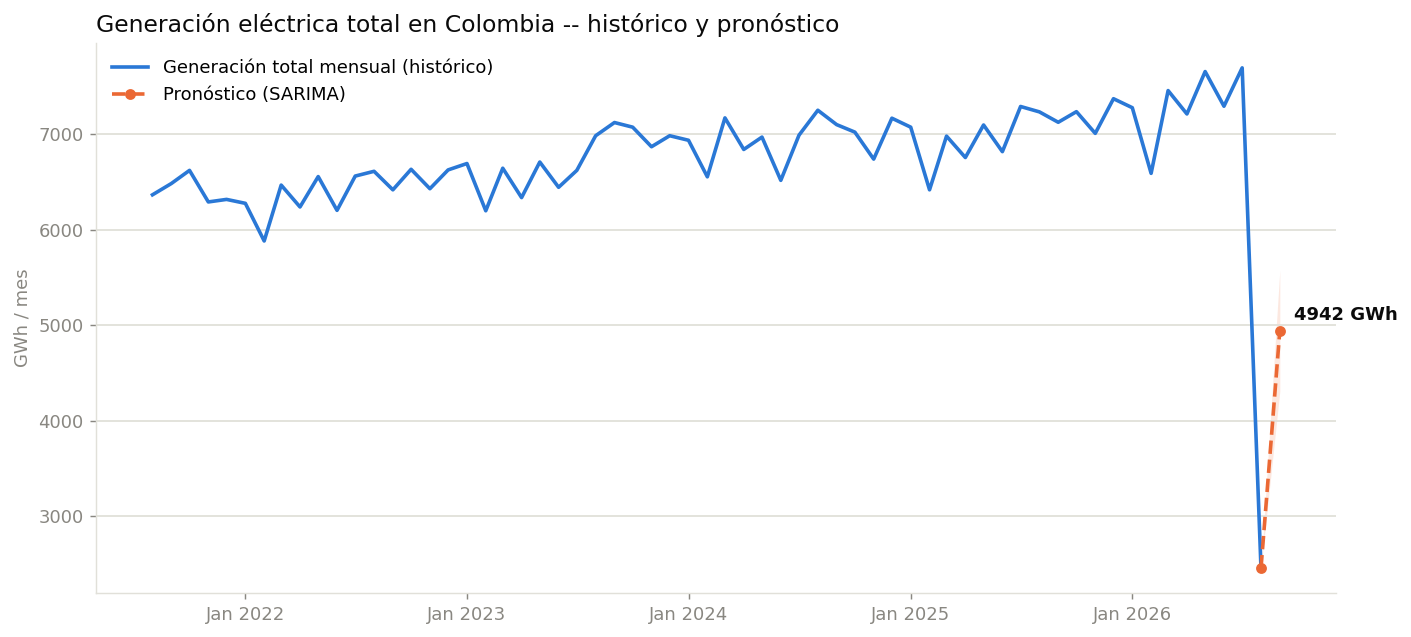

In [ ]:
corte = serie.index[-1] - pd.DateOffset(years=5)
serie_reciente = serie.loc[serie.index >= corte]

fig, ax = plt.subplots(figsize=(11, 5), dpi=130)

ax.plot(
    serie_reciente.index, serie_reciente.values,
    color=COLOR_HIST, linewidth=2, label="Generación total mensual (histórico)",
)
ax.plot(
    [serie.index[-1], pron["fecha"]], [serie.iloc[-1], pron["media"]],
    color=COLOR_FCST, linewidth=2, linestyle="--", marker="o", markersize=5,
    label="Pronóstico (SARIMA)",
)
ax.fill_between(
    [serie.index[-1], pron["fecha"]], [serie.iloc[-1], pron["li"]], [serie.iloc[-1], pron["ls"]],
    color=COLOR_FCST, alpha=0.15, linewidth=0,
)
ax.annotate(
    f"{pron['media']:.0f} GWh",
    (pron["fecha"], pron["media"]),
    textcoords="offset points", xytext=(8, 6),
    color=COLOR_INK, fontsize=10, fontweight="bold",
)

ax.set_title(
    "Generación eléctrica total en Colombia -- histórico y pronóstico",
    color=COLOR_INK, fontsize=13, loc="left",
)
ax.set_ylabel("GWh / mes", color=COLOR_MUTED)
ax.grid(axis="y", color=COLOR_GRID, linewidth=1)
ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_color(COLOR_GRID)
ax.spines["bottom"].set_color(COLOR_GRID)
ax.tick_params(colors=COLOR_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("pronostico_generacion_upme.png", dpi=150)
plt.show()

## Próximos pasos posibles

- Sacar un [App Token](https://www.datos.gov.co/profile/edit/developer_settings) si vas a correr esto seguido (agente diario, por ejemplo), para no compartir el límite de tasa anónimo.
- Sumar la [API de XM](https://github.com/EquipoAnaliticaXM/API_XM) para tener demanda/generación con granularidad diaria o horaria, y ahí sí construir un pronóstico semanal real.
- Ajustar el orden del SARIMA (`order`, `seasonal_order`) o probar `auto_arima` de `pmdarima` si quieres optimizar el modelo en vez de usar los parámetros por defecto.